In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Helvetica",
})
import numpy as np
import os
from classy_sz import Class as Class_sz
import tszpower as tsz

/Users/licongxu/csd3/tsz_project/tszpower/tszpower/__init__.py:1: DeprecationWarning: compute_class_szfast is deprecated. Use initialize_classy_szfast instead.
  from .config import classy_sz
/Users/licongxu/envs/cmbagent_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Using class_sz

In [2]:
allpars = {
    'omega_b': 0.02242,
    'omega_cdm':  0.1193,
    'H0': 67.66,
    'tau_reio': 0.0544,
    'ln10^{10}A_s': 2.972,
    # 'sigma8': 0.81,
    'n_s': 0.9665,
    "cosmo_model": 0, # 1: use mnu-lcdm emulators; 0: use lcdm with fixed neutrino mass
    "B": 1.41,

    'M_min': 1e14*0.6766,
    'M_max': 1e15*0.6766,

    'z_min' : 0.5,
    'z_max' : 3.0,

    "P0GNFW": 8.130,
    "c500": 1.156,
    "gammaGNFW": 0.3292,
    "alphaGNFW": 1.0620,
    "betaGNFW":5.4807,

    'jax' : 0, 
}

In [3]:
precision_params = {
'x_outSZ': 4., # truncate profile beyond x_outSZ*r_s

'n_m_pressure_profile' :500, # default: 100, decrease for faster
'n_z_pressure_profile' :500, # default: 100, decrease for faster


'use_fft_for_profiles_transform' : 1, # use fft's or not.
# only used if use_fft_for_profiles_transform set to 1
'N_samp_fftw' :8192,
'x_min_gas_pressure_fftw' : 1e-12,
'x_max_gas_pressure_fftw' : 1e12,


'ndim_redshifts' :100,


'redshift_epsabs': 1.0e-40,
'redshift_epsrel': 0.0001,


'mass_epsabs': 1.0e-40,
'mass_epsrel': 0.0001
}
classy_sz = Class_sz()
classy_sz.set(allpars)
classy_sz.set(precision_params)
classy_sz.set({

'output': 'tSZ_tSZ_1h,tSZ_tSZ_2h',
'skip_input':0,
"ell_min" : 2,
"ell_max" : 1100,
# 'dell': 10.,
'dlogell': 0.1,


'mass_function' : 'T08M500c',
'pressure_profile':'GNFW', # can be Battaglia, Arnaud, etc
'no_spline_in_tinker': 1,
'HMF_prescription_NCDM': 1,


})
classy_sz.compute_class_szfast()

/Users/licongxu/envs/cmbagent_env/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3549: DeprecationWarning: compute_class_szfast is deprecated. Use initialize_classy_szfast instead.
  exec(code_obj, self.user_global_ns, self.user_ns)
/Users/licongxu/envs/cmbagent_env/lib/python3.12/site-packages/mcfit/mcfit.py:130: UserWarning: use backend='jax' if desired
  warnings.warn("use backend='jax' if desired")


In [4]:
l = np.asarray(classy_sz.cl_sz()['ell'])
cl_yy_1h = np.asarray(classy_sz.cl_sz()['1h'])
cl_yy_2h = np.asarray(classy_sz.cl_sz()['2h'])

In [5]:
l

array([   2.        ,    2.21034184,    2.44280552,    2.69971762,
          2.9836494 ,    3.29744254,    3.6442376 ,    4.02750541,
          4.45108186,    4.91920622,    5.43656366,    6.00833205,
          6.64023385,    7.33859334,    8.11039993,    8.96337814,
          9.90606485,   10.94789478,   12.09929493,   13.37178888,
         14.7781122 ,   16.33233983,   18.050027  ,   19.94836491,
         22.04635276,   24.36498792,   26.92747607,   29.75946345,
         32.88929354,   36.34829074,   40.17107385,   44.39590256,
         49.06506039,   54.22527784,   59.92820009,   66.23090392,
         73.19646889,   80.89460872,   89.40236899,   98.80489821,
        109.19630007,  120.68057519,  133.37266208,  147.3995874 ,
        162.90173733,  180.0342626 ,  198.96863128,  219.8943449 ,
        243.02083504,  268.57955937,  296.82631821,  328.0438146 ,
        362.54448375,  400.67361995,  442.81283241,  489.38386453,
        540.85281485,  597.73480193,  660.59911982,  730.07493

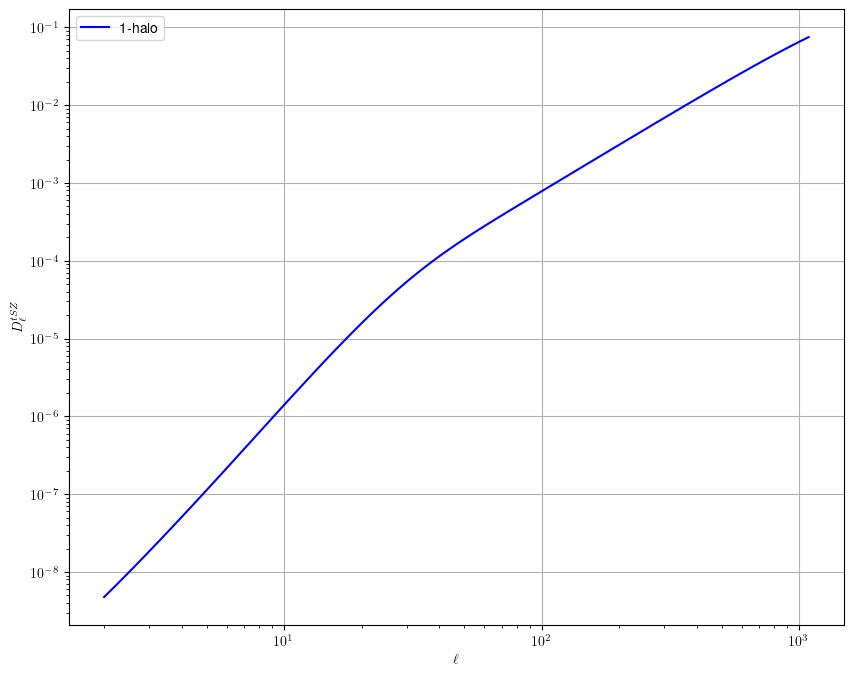

In [6]:
plt.figure(figsize=(10,8))
plt.loglog(l, cl_yy_1h, label='1-halo', color='blue')
# plt.loglog(l, cl_yy_2h, label='2-halo', color='red')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$D_\ell^{tSZ}$')
plt.legend()
plt.grid()
plt.show()


# Using tszpower

In [7]:
allpars = {
    'omega_b': 0.02242,
    'omega_cdm':  0.1193,
    'H0': 67.66,
    'tau_reio': 0.0544,
    'ln10^{10}A_s': 2.972,
    # 'sigma8': 0.81,
    'n_s': 0.9665,
    "cosmo_model": 0, # 1: use mnu-lcdm emulators; 0: use lcdm with fixed neutrino mass
    "B": 1.41,

    'M_min': 1e14*0.6766,
    'M_max': 1e15*0.6766,

    'z_min' : 0.5,
    'z_max' : 3.0,

    "P0GNFW": 8.130,
    "c500": 1.156,
    "gammaGNFW": 0.3292,
    "alphaGNFW": 1.0620,
    "betaGNFW":5.4807,

    'jax' : 1, 
}
tsz.classy_sz.set(allpars)
tsz.initialise()

/var/folders/pk/xl4598515pb7q2jfw1tdzyr00000gn/T/ipykernel_65869/657823160.py:27: DeprecationWarning: compute_class_szfast is deprecated. Use initialize_classy_szfast instead.
  tsz.initialise()


In [9]:
ell = tsz.get_ell_range()
D_ell_yy  = tsz.compute_Dell_yy(params_value_dict=allpars)

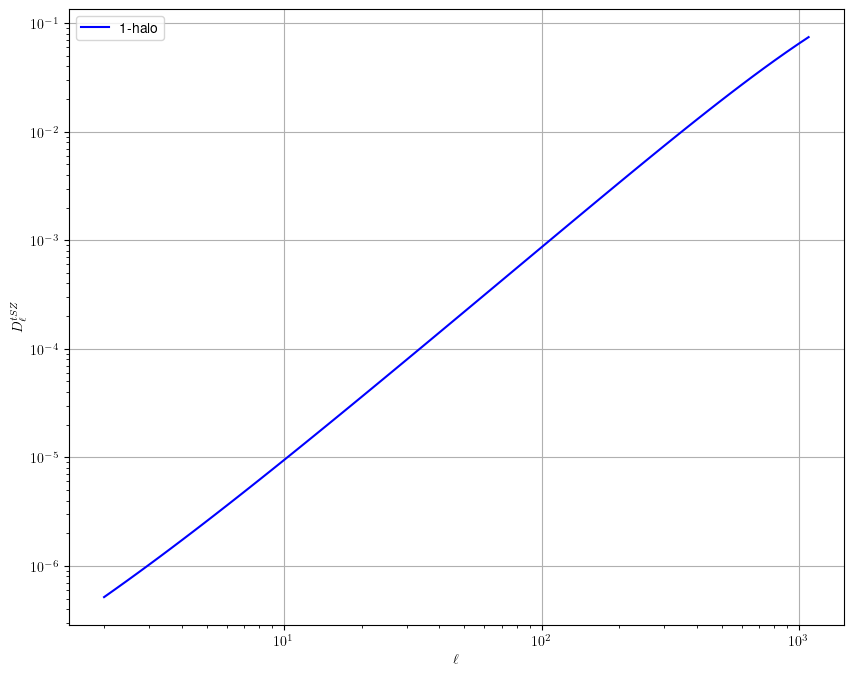

In [10]:
plt.figure(figsize=(10,8))
plt.loglog(ell, D_ell_yy, label='1-halo', color='blue')
# plt.loglog(l, cl_yy_2h, label='2-halo', color='red')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$D_\ell^{tSZ}$')
plt.legend()
plt.grid()
plt.show()


# Compare tszpower with class_sz

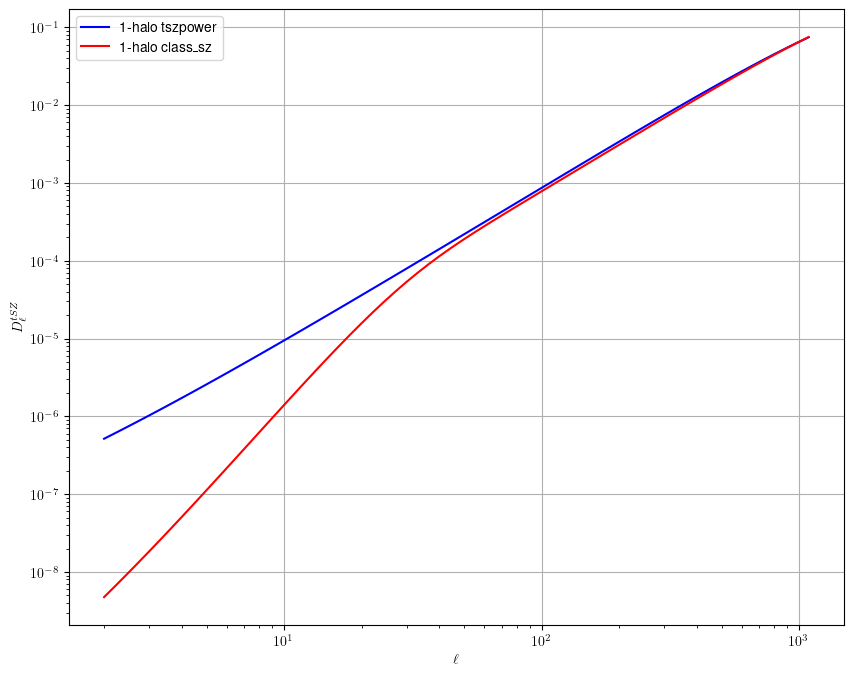

In [11]:
plt.figure(figsize=(10,8))
plt.loglog(ell, D_ell_yy, label='1-halo tszpower', color='blue')
plt.loglog(l, cl_yy_1h, label='1-halo class_sz', color='red')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$D_\ell^{tSZ}$')
plt.legend()
plt.grid()
plt.show()


In [13]:
# Ratio:
D_ell_yy/cl_yy_1h

Array([108.4927547 ,  92.39998877,  78.47357361,  66.47450654,
        56.17832556,  47.37711428,  39.88059125,  33.51648976,
        28.1303528 ,  23.58488787,  19.75900875,  16.5466765 ,
        13.8556188 ,  11.60600869,   9.72914814,   8.16620118,
         6.86700004,   5.78894206,   4.89598573,   4.15774871,
         3.5487061 ,   3.04748335,   2.63623701,   2.30011402,
         2.02677932,   1.80600093,   1.62933303,   1.48957419,
         1.38078733,   1.29781288,   1.23610314,   1.1915697 ,
         1.16051954,   1.1396747 ,   1.12623421,   1.11792031,
         1.11297338,   1.11010022,   1.1083989 ,   1.1072771 ,
         1.10637105,   1.10547111,   1.10446004,   1.1032683 ,
         1.10184616,   1.10014909,   1.09813166,   1.09574619,
         1.0929435 ,   1.08967503,   1.08589583,   1.08156808,
         1.07666519,   1.07152203,   1.06510402,   1.05847605,
         1.05133524,   1.04374596,   1.03579606,   1.02760341,
         1.01932303,   1.01114857,   1.00330388,   0.99